In [1]:
suppressPackageStartupMessages(library(dplyr)) 
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(Seurat)
library(Signac)
library(harmony)

source("/projects/ps-renlab2/y2xie/scripts/basics.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_doubletfinder_mo.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_vg.R")
source("/projects/ps-renlab2/y2xie/scripts/DPT_help.R")
library(repr)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.2”
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘harmony’ was built under R version 4.3.2”
Loading required package: Rcpp

Warning message:
“package ‘dichromat’ was built under R version 4.3.2”
Warning message:
“package ‘viridis’ was built under R version 4.3.2”
Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




In [4]:
path <- '/projects/ps-renlab2/y2xie/projects/77.LC/78.FNIH_DPT_IGM_240813/'
subdir <- "./"

### QC of DNA modality

In [131]:
dna_meta <- read.table(paste0(path, "scripts/Multiome_DNA_ref.txt"))
rna_meta <- read.csv(paste0(path, "scripts/Multiome_RNA_ref.txt"), sep = "\t", header = F)
meta <- read.table(paste0(path, "scripts/liver_pool_metadata.xls"))
dsample <- meta$V1
rsample <- meta$V2

dsample
rsample

[1] "QY_2576" "QY_2578" "QY_2580" "QY_2582" "QY_2584" "QY_2586" "QY_2588"
 [8] "QY_2590" "QY_2592" "QY_2594" "QY_2596" "QY_2598" "LV003"   "LV004"

[1] "QY_2577" "QY_2579" "QY_2581" "QY_2583" "QY_2585" "QY_2587" "QY_2589"
 [8] "QY_2591" "QY_2593" "QY_2595" "QY_2597" "QY_2599" "QY_2556" "QY_2558"

### Check libraries summary

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Confidently.mapped.read.pairs,0.9443,0.9444,0.9187,0.919,0.9431,0.9422,0.9192,0.9176,0.9399,0.9396,0.9152,0.9143,0.9502,0.9246
Sequenced.read.pairs,545366518,501906104,549603522,457505304,574194625,443181795,426820191,430927640,765290540,656136035,521587571,547028392,229351114,257844792
Sequencing.saturation,0.8575,0.8408,0.7286,0.6919,0.8808,0.8572,0.6507,0.6619,0.8702,0.8619,0.6346,0.6751,0.5182,0.4172


Using Sample.ID, NA, Sequenced.read.pairs, Sequencing.saturation as id variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


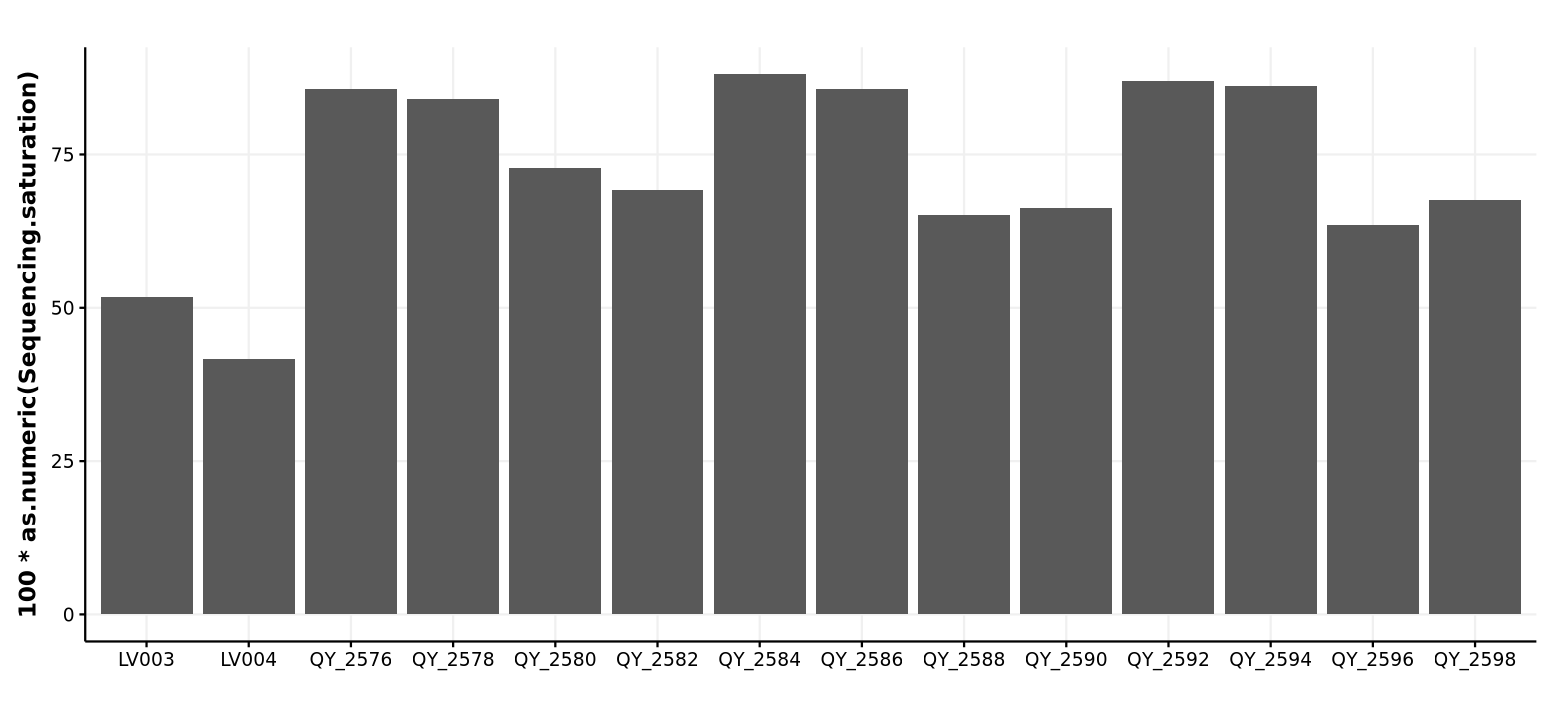

In [109]:
lib_meta <- list()
for (f in dsample){
    tmp <- read.csv(paste0("../DNA/", f, "/outs/summary.csv")) %>% t
    lib_meta[[f]] <- tmp
}
lib_meta <- do.call(cbind, lib_meta) %>% as.data.frame

lib_meta[c('Confidently.mapped.read.pairs', 'Sequenced.read.pairs', 'Sequencing.saturation'),]

lib_meta[c('Sample.ID', 'Confidently.mapped.read.pairs, ', 'Sequenced.read.pairs', 'Sequencing.saturation'),] %>% 
t %>% as.data.frame %>%
reshape2::melt() %>%
ggplot(aes(x = Sample.ID, y = 100*as.numeric(Sequencing.saturation))) + 
geom_col() + xlab("") + 
theme_Publication() + 
scale_fill_Publication()

In [113]:
unlist(lib_meta['Sequenced.read.pairs', ]) %>% as.numeric %>% summary

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
229351114 433991179 511746838 493338867 548959740 765290540 

Using sample, Number.of.Reads, Estimated.Number.of.Cells, Median.UMI.Counts.per.Cell, Median.Genes.per.Cell, Sequencing.Saturation as id variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


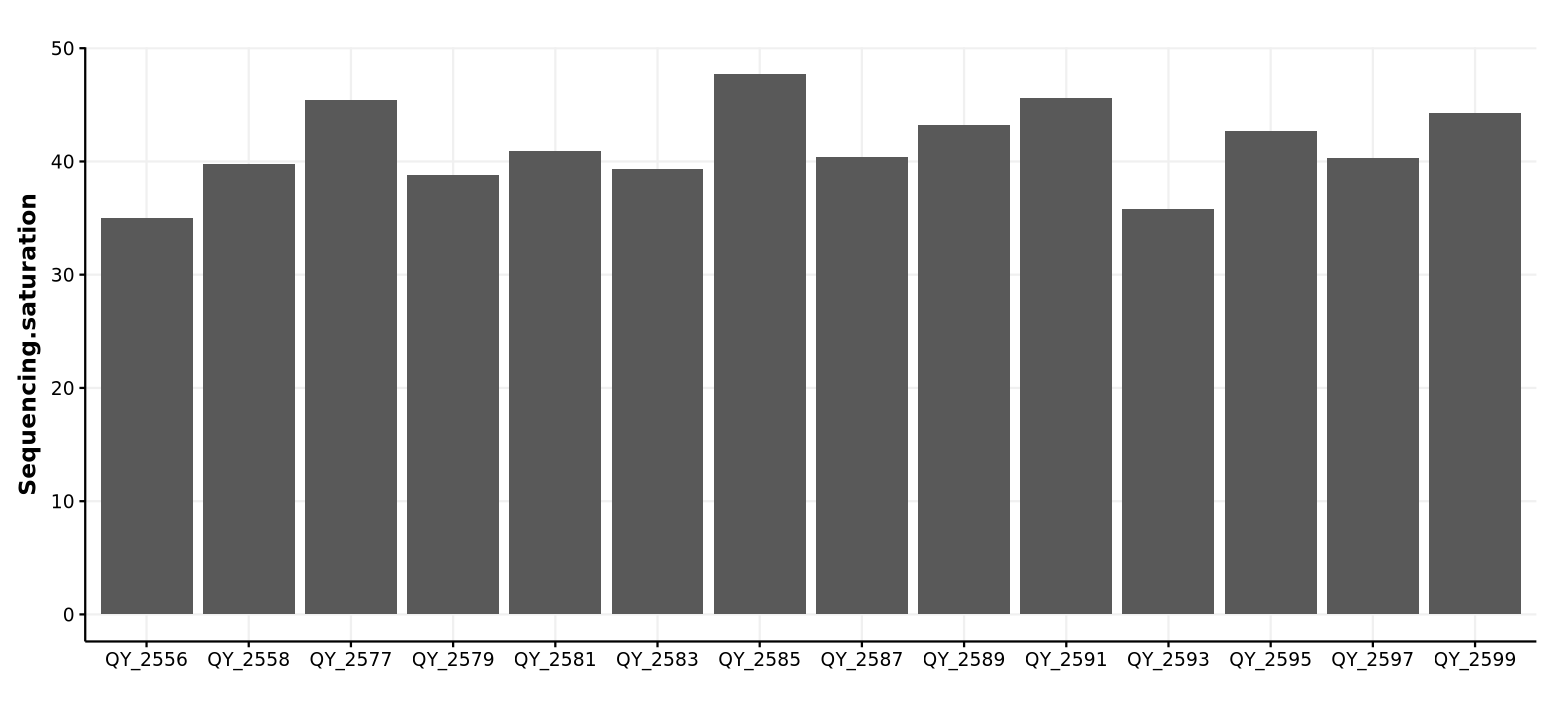

In [33]:
### Read RNA sample
igm <- list()
for (f in rsample){
    tmp <- read.csv(paste0(path, "/RNA/", f, "/outs/metrics_summary.csv")) %>% 
    mutate(sample = f) %>% t %>% as.data.frame
    igm[[f]] <- tmp
}
igm <- do.call(cbind, igm)
colnames(igm) <- igm["sample",]

options(repr.plot.width = 13, repr.plot.height = 6)
igm[c("sample", "Number.of.Reads", "Estimated.Number.of.Cells", "Median.UMI.Counts.per.Cell", "Median.Genes.per.Cell", "Sequencing.Saturation"), ] %>%
t %>% as.data.frame %>%
reshape2::melt() %>%
mutate(Sequencing.saturation = as.numeric(gsub("%", "", Sequencing.Saturation))) %>%
ggplot(aes(x = sample, y = Sequencing.saturation)) + 
geom_col() + xlab("") + 
theme_Publication() + 
scale_fill_Publication()

### 10X formats FRiP plot 

In [168]:
frip <- list()
for (s in dsample){
    frip[[s]] <- ImportArcFRiP(raw_count = paste0(path, "09.macs2/", s, "_clean_fragments.tsv.gz_Count.xls"),
                         frip_count = paste0(path, "09.macs2/", s, "_FRiP_fragments.tsv_Count.xls"))
    frip[[s]]$sample <- s
}

In [169]:
names(frip)

[1] "QY_2576" "QY_2578" "QY_2580" "QY_2582" "QY_2584" "QY_2586" "QY_2588"
 [8] "QY_2590" "QY_2592" "QY_2594" "QY_2596" "QY_2598" "LV003"   "LV004"

In [171]:
i = 2
f <- names(frip)[i]
xcut = 700
ycut = 0.35
ycut2 = 0.7

valid <- PlotArcFRiP_d(frip[[f]], xcut_low = xcut, 
                              ycut_low = ycut, 
                              ycut_high = ycut2, 
                              prefix = f)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


In [64]:
cutoff <- data.frame(sample = names(frip),
                   xcut = c(700, 700, 1000, 1000, 700, 700, 700, 700, 700, 700, 1000, 1000, 700, 700),
                   ycut = c(0.3, 0.35, 0.6, 0.6, 0.3, 0.3, 0.6, 0.6, 0.3, 0.4, 0.55, 0.55, 0.4, 0.6), 
                   ycut2 = c(0.7, 0.7, 0.85, 0.85, 0.65, 0.65, 0.85, 0.85, 0.75, 0.7, 0.85, 0.85, 0.7, 0.85))

In [17]:
valid <- list()
for (f in cutoff$sample){
    valid[[f]] <- PlotArcFRiP_d(frip[[f]], xcut_low = cutoff[cutoff$sample ==f, "xcut"], 
                              ycut_low = cutoff[cutoff$sample ==f, "ycut"], 
                              ycut_high = cutoff[cutoff$sample ==f, "ycut2"], 
                              prefix = f)
}

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


## Manual filtering: DNA  + RNA

In [65]:
valid <- list()

In [66]:
translate <- read.table("/projects/ps-renlab/y2xie/projects/genome_ref/arc_bc-translation.txt", header = T, row.names = 1, sep = "\t")
translate$atac <- paste0(translate$atac, "-1")
translate$rna <- paste0(translate$rna, "-1")

In [176]:
i = 2
ds = dsample[i]
rs = rsample[i]

tmp1 <- read.table(paste0(path, "09.macs2/", subdir, ds, "_clean_fragments.tsv.gz_Count.xls")) %>% 
setNames(c("dna_raw", "dna_unique")) %>%
dplyr::select(dna_unique)

rownames(tmp1) <- translate[match(rownames(tmp1), translate$atac),]$rna

tmp2 <- Read10X(paste0(path, "/RNA/", rs, "/outs/raw_feature_bc_matrix")) %>% 
colSums() %>% as.data.frame() %>% 
setNames("rna")

tf <- merge(x = tmp1, y = tmp2, by = 0) %>% 
setNames(c("bc", "dna_count", "rna_count"))

In [ ]:
xcutoff = 700
ycutoff = 500
valid[[i]] <- PlotArcPair_d(pair = tf, dcutoff = xcutoff, rcutoff = ycutoff, 
                            prefix = paste0(ds, "_", rs), names = "rna")

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


# Summary: liver pools IGM

In [146]:
valid <- list()
for (i in 1:length(dsample)){
    ds = dsample[i]
    rs = rsample[i]
    if (ds == "QY_2578"){
        next
    }
    valid1 <- read.table(paste0(ds, "_", rs, "_valid_cells.xls"), sep = "\t", header = T)
    valid2 <- read.table(paste0(ds, "_PF_cells.txt"), sep = "\t")[,1:6]
    colnames(valid2) <- c("atac", "all", "all_dedup", "peak", "peak_dedup", "frip")
    valid[[ds]] <- merge(valid1, valid2, by = "atac") %>% mutate(dsample = ds, rsample = rs)
}

valid <- do.call(rbind, valid)
cnumber <- table(valid$dsample) %>% as.data.frame 
valid <- merge(valid, meta, by.x = "dsample", by.y = "V1")
valid$target <- gsub("^([^_]+)_([^_-]+).*", "\\2", valid$V4)
valid[valid$target == "H3K27me", ]$target <- "H3K27me3"

head(valid)

,dsample,atac,rna,dna_count,rna_count,all,all_dedup,peak,peak_dedup,frip,rsample,V2,V3,V4,target
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,LV003,AAACAAGCAAAGGCCT-1,GGCTAGTGTGTGTGGT-1,6375,609,11044,6375,5031,2904,0.4555294,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac
2,LV003,AAACAAGCAACAACAT-1,GGCTAGTGTTACATCC-1,4737,408,7929,4737,3727,2205,0.4654845,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac
3,LV003,AAACAAGCAAGTGGCT-1,GGCTAGTGTGAGCGAA-1,5325,3615,8970,5325,4900,2877,0.5402817,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac
4,LV003,AAACAAGCATCCTGCA-1,GGCTAGTGTTTCCTCC-1,5345,1183,8355,5345,4732,3006,0.5623948,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac
5,LV003,AAACCAGGTAAGTGGC-1,GTTTAACCACCCTCAC-1,1445,2467,2351,1445,1268,777,0.5377163,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac
6,LV003,AAACCAGGTACGTAAG-1,GTTTAACCATCCGTAA-1,1236,5983,2021,1236,986,605,0.4894822,QY_2556,QY_2556,Liver,pool-1_H3K27ac,H3K27ac


Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


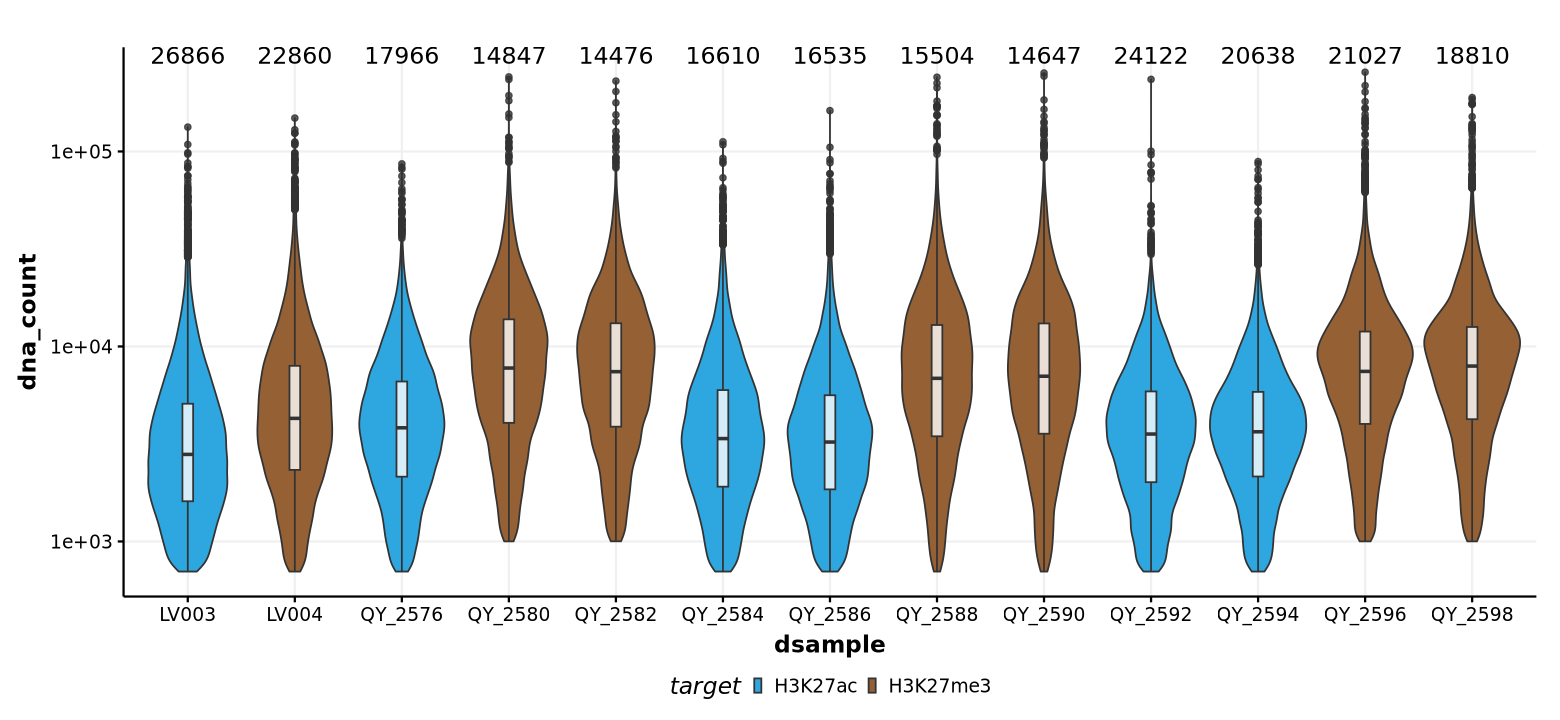

In [157]:
options(repr.plot.width = 13, repr.plot.height = 6)
valid %>%
ggplot(aes(x = dsample, y = dna_count)) + 
geom_violin(aes(fill = target)) + 
geom_boxplot(fill = "white", alpha = 0.8, width = 0.1) + 
geom_text(data = cnumber, aes(x = Var1, y = max(valid$dna_count), label = Freq), 
              vjust = -0.5, size = 5, color = "black") + 
scale_y_log10() + 
theme_Publication() +
scale_fill_manual(values = c("#2EA7E0", "#956134"))

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


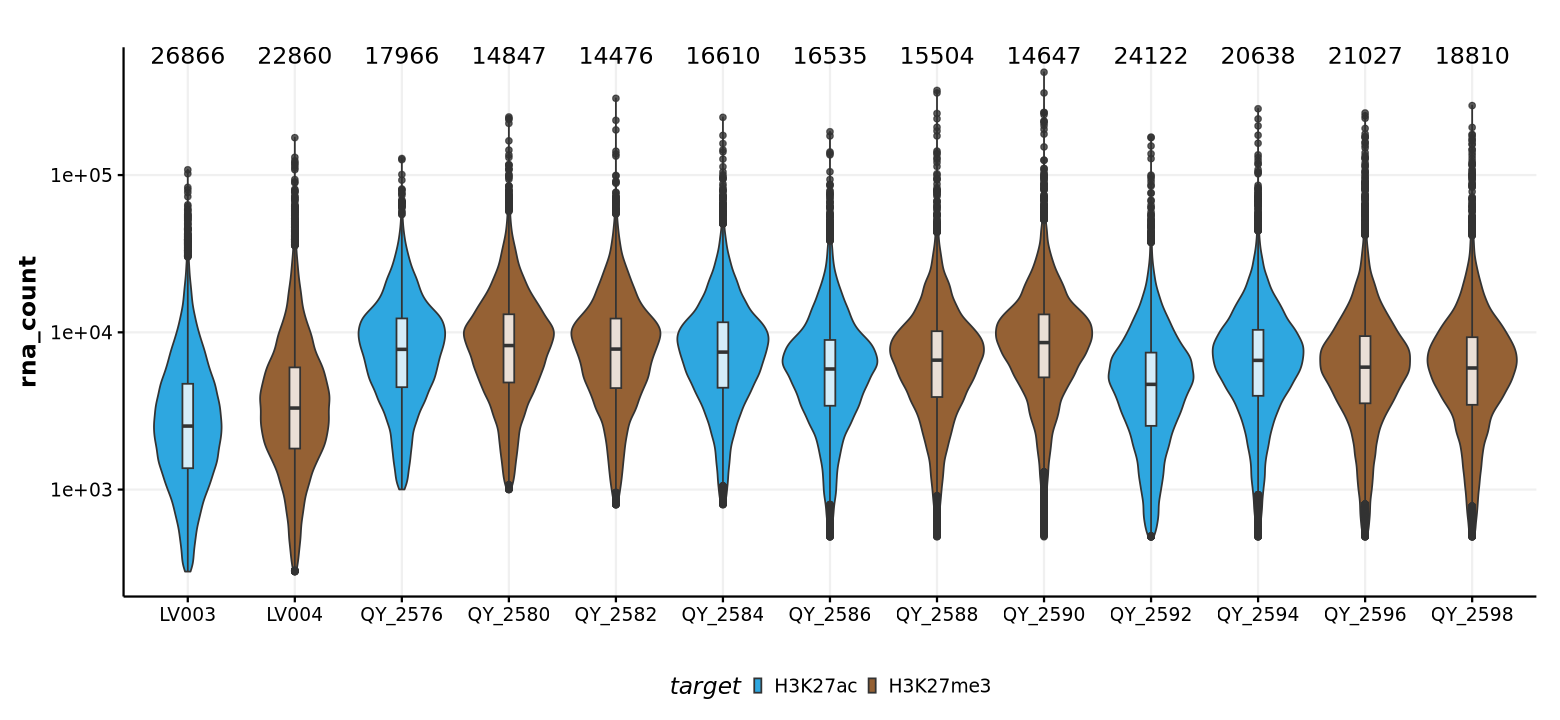

In [162]:
options(repr.plot.width = 13, repr.plot.height = 6)
valid %>%
ggplot(aes(x = dsample, y = rna_count)) + 
geom_violin(aes(fill = target)) + 
geom_boxplot(fill = "white", alpha = 0.8, width = 0.1) + 
geom_text(data = cnumber, aes(x = Var1, y = max(valid$rna_count), label = Freq), 
              vjust = -0.5, size = 5, color = "black") + 
scale_y_log10() + xlab("") + 
theme_Publication() +
scale_fill_manual(values = c("#2EA7E0", "#956134"))

In [167]:
valid %>% group_by(target) %>% summarise(median(frip))

target,median(frip)
<chr>,<dbl>
H3K27ac,0.5277541
H3K27me3,0.7125466


Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


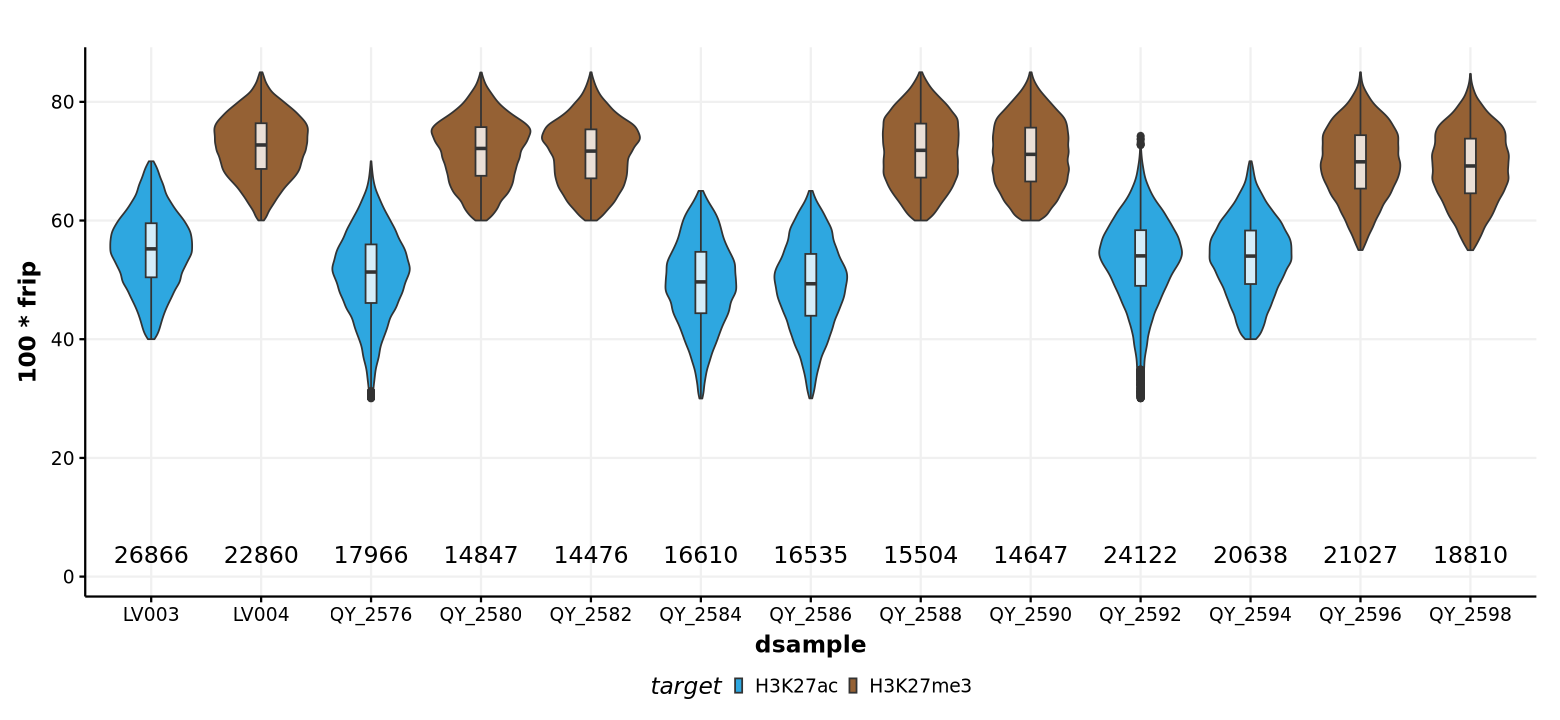

In [163]:
options(repr.plot.width = 13, repr.plot.height = 6)
valid %>%
ggplot(aes(x = dsample, y = 100*frip)) + 
geom_violin(aes(fill = target)) + 
geom_boxplot(fill = "white", alpha = 0.8, width = 0.1) + 
geom_text(data = cnumber, aes(x = Var1, y = max(valid$frip), label = Freq), 
              vjust = -0.5, size = 5, color = "black") + 
theme_Publication() +
scale_fill_manual(values = c("#2EA7E0", "#956134"))